# Assignment 2

In [3]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package quantum-espresso.
Preparing to unpack .../quantum-espresso_6.7-2build1_amd64.deb ...
Unpacking quantum-espresso (6.7-2build1) ...
Selecting previously unselected package quantum-espresso-data.
Preparing to unpack .../quantum-espresso-data_6.7-2build1_all.deb ...
Unpacking quantum-espresso-data (6.7-2build1) ...
Setting up quantum-espresso-data (6.7-2build1) ...
Setting up libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Setting up quantum-espresso (6.7-2build1) ...
Processing triggers for libc-bin (2.35-0ubunt

In [4]:
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)

/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.13/dist-packages/ase/__init__.py


In [5]:
from ase.calculators.espresso import EspressoProfile
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.calculators.espresso import Espresso

plt.rcParams['figure.dpi'] = 110


In [6]:
!mkdir -p pseudo
!wget -q -O gbrv.tar.gz https://www.physics.rutgers.edu/gbrv/all_pbe_UPF_v1.5.tar.gz
!tar -xzf gbrv.tar.gz -C pseudo

import glob, os, shutil

for f in glob.glob('pseudo/*_*.UPF'):
    new_name = os.path.basename(f).split('_')[0].capitalize() + '.UPF'
    shutil.move(f, os.path.join('pseudo', new_name))

# We only actually need a few elements here: O and C
print(sorted(glob.glob('pseudo/*.UPF'))[:10], '...')

['pseudo/Ag.UPF', 'pseudo/Al.UPF', 'pseudo/As.UPF', 'pseudo/Au.UPF', 'pseudo/B.UPF', 'pseudo/Ba.UPF', 'pseudo/Be.UPF', 'pseudo/Bi.UPF', 'pseudo/Br.UPF', 'pseudo/C.UPF'] ...


In [7]:
def pseudo_filename(symbol):
    return f'{symbol}.UPF'

def recommended_cutoffs(symbol):
    """GBRV is designed around one uniform cutoff rather than per-element
    values: ~40 Ry for ecutwfc, and since these are ultrasoft
    pseudopotentials, ecutrho should be 8-12x that (we use 8x)."""
    return 40, 320

In [8]:
for el in ['N', 'Cl', 'F']:
    fn = pseudo_filename(el)
    ecutwfc, ecutrho = recommended_cutoffs(el)
    print(f'{el}: {fn}  (recommended ecutwfc={ecutwfc} Ry, ecutrho={ecutrho} Ry)')

N: N.UPF  (recommended ecutwfc=40 Ry, ecutrho=320 Ry)
Cl: Cl.UPF  (recommended ecutwfc=40 Ry, ecutrho=320 Ry)
F: F.UPF  (recommended ecutwfc=40 Ry, ecutrho=320 Ry)


Now we are ready to do the questions

**N₂ and CO are isoelectronic — same number of valence electrons, similar bonding picture. Compute N₂'s bond length and vibrational frequency and compare directly against your CO numbers. Are they as similar as the 'isoelectronic' label suggests they should be?**

In [23]:
def make_boxed_molecule(symbols, positions, box=12.0):
    """Put a small molecule at the center of a cubic vacuum box."""
    atoms = Atoms(symbols, positions=positions)
    atoms.set_cell([box, box, box])
    atoms.center()
    atoms.pbc = True  # QE always requires this, even for a 'molecule'
    return atoms

In [8]:
pseudopotentials = {'N': pseudo_filename('N')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'fixed'},
    'electrons': {'conv_thr': 1.0e-8},
}


In [14]:
bond_lengths = np.arange(0.9, 1.3, 0.05)  # Angstrom
N2_energies = []

for d in bond_lengths:
    atoms = make_boxed_molecule(['N', 'N'], [[0, 0, 0], [0, 0, d]])
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                           kpts=(1, 1, 1))
    N2_energies.append(atoms.get_potential_energy())
    print(f'd = {d:.2f} A   E = {N2_energies[-1]:.4f} eV')

d = 0.90 A   E = -542.5570 eV
d = 0.95 A   E = -545.2803 eV
d = 1.00 A   E = -546.9069 eV
d = 1.05 A   E = -547.7449 eV
d = 1.10 A   E = -548.0242 eV
d = 1.15 A   E = -547.9146 eV
d = 1.20 A   E = -547.5399 eV
d = 1.25 A   E = -546.9900 eV


In [9]:
N2_energies = [-542.5570,-545.2803,-546.9069,-547.7449,-548.0242,-547.9146,-547.5399,-546.9900]
bond_lengths = [0.9,0.95,1.00,1.05,1.10,1.15,1.20,1.25]

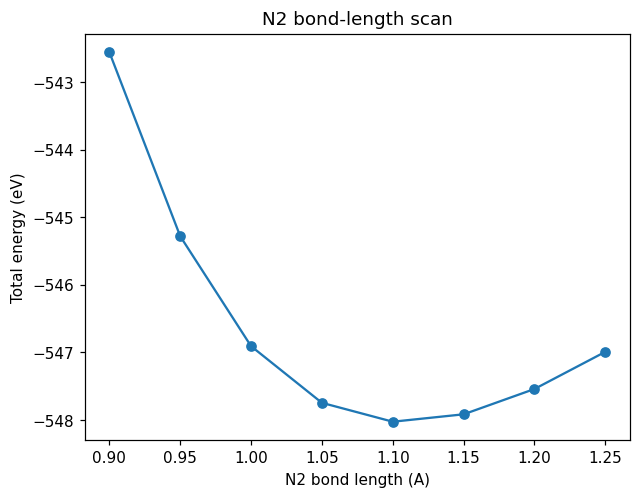

In [10]:
plt.plot(bond_lengths, N2_energies, 'o-')
plt.xlabel('N2 bond length (A)')
plt.ylabel('Total energy (eV)')
plt.title('N2 bond-length scan')
plt.show()


In [12]:
# Fit a parabola near the minimum: E(d) ~ E0 + 0.5*k*(d-d0)^2
coeffs = np.polyfit(bond_lengths, N2_energies, 2)   # [a, b, c] for a*d^2+b*d+c
a, b, c = coeffs
d0 = -b / (2 * a)          # vertex of the parabola = equilibrium bond length
k_eV_per_A2 = 2 * a        # curvature -> force constant
print(f'Equilibrium bond length: {d0:.3f} A  ')

# Convert the force constant to a vibrational wavenumber using the
# reduced mass  and standard unit conversions.
import scipy.constants as sc
k_SI = k_eV_per_A2 * sc.e * 1e20               # eV/A^2 -> J/m^2
mu = (14 * 14) / (14+ 14) * sc.atomic_mass  # reduced mass, kg
omega = np.sqrt(k_SI / mu)                      # rad/s
wavenumber = omega / (2 * np.pi * sc.c) / 100    # -> cm^-1
print(f'Estimated vibrational wavenumber: {wavenumber:.0f} cm^-1  ')
print('bond strength k:',k_SI)


Equilibrium bond length: 1.127 A  
Estimated vibrational wavenumber: 2842 cm^-1  
bond strength k: 3331.062551511746


While they both have almost same bond lengths (around 1.1) but their vibration energy is very different. This is because of the different masses of the nuclei. So they are not as similar as isoelectronic suggests them to be

**Cl₂ — a much heavier diatomic molecule. How does its bond length and vibrational frequency compare to CO/N₂, and how much of that difference do you think comes from bond strength vs. simply the heavier reduced mass?**

In [17]:
pseudopotentials = {'Cl': pseudo_filename('Cl')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'fixed'},
    'electrons': {'conv_thr': 1.0e-8},
}


In [19]:
bond_lengths = np.arange(1.8, 2.2, 0.05)  # Angstrom
energies = []

for d in bond_lengths:
    atoms = make_boxed_molecule(['Cl', 'Cl'], [[0, 0, 0], [0, 0, d]])
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                           kpts=(1, 1, 1))
    energies.append(atoms.get_potential_energy())
    print(f'd = {d:.2f} A   E = {energies[-1]:.4f} eV')

d = 1.80 A   E = -905.2419 eV
d = 1.85 A   E = -905.5054 eV
d = 1.90 A   E = -905.6731 eV
d = 1.95 A   E = -905.7641 eV
d = 2.00 A   E = -905.7942 eV
d = 2.05 A   E = -905.7760 eV
d = 2.10 A   E = -905.7198 eV
d = 2.15 A   E = -905.6342 eV
d = 2.20 A   E = -905.5261 eV


In [13]:
bond_lengths = [1.8,1.85,1.9,1.95,2.0,2.05,2.10,2.15,2.2]
energies = [-905.2419,-905.5054,-905.6731,-905.76441,-905.7942,-905.7760,-905.7198,-905.6342,-905.52261]

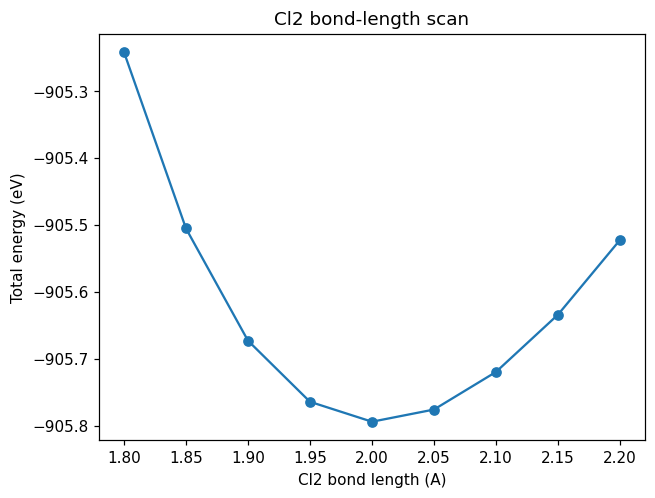

In [14]:
plt.plot(bond_lengths, energies, 'o-')
plt.xlabel('Cl2 bond length (A)')
plt.ylabel('Total energy (eV)')
plt.title('Cl2 bond-length scan')
plt.show()


In [16]:
# Fit a parabola near the minimum: E(d) ~ E0 + 0.5*k*(d-d0)^2
coeffs = np.polyfit(bond_lengths, energies, 2)   # [a, b, c] for a*d^2+b*d+c
a, b, c = coeffs
d0 = -b / (2 * a)          # vertex of the parabola = equilibrium bond length
k_eV_per_A2 = 2 * a        # curvature -> force constant
print(f'Equilibrium bond length: {d0:.3f} A  ')

# Convert the force constant to a vibrational wavenumber using the
# reduced mass and standard unit conversions.
import scipy.constants as sc
k_SI = k_eV_per_A2 * sc.e * 1e20               # eV/A^2 -> J/m^2
mu = (35.45 * 35.45) / (35.45 + 35.45) * sc.atomic_mass  # reduced mass, kg
omega = np.sqrt(k_SI / mu)                      # rad/s
wavenumber = omega / (2 * np.pi * sc.c) / 100    # -> cm^-1
print(f'Estimated vibrational wavenumber: {wavenumber:.0f} cm^-1  ')
print('bond strength K:',k_SI)


Equilibrium bond length: 2.026 A  
Estimated vibrational wavenumber: 563 cm^-1  
bond strength K: 330.5712094380066


We can see that the bond strength of N2 is much higher than that of Cl2 (3300 vs 330) , so the reduced vibration is a combination of both bond strength and higher reduced mass of Cl2

**F₂ — famously has a weaker bond than you might predict from fluorine's high electronegativity. Does your computed vibrational frequency support that?**

In [29]:
pseudopotentials = {'F': pseudo_filename('F')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'fixed'},
    'electrons': {'conv_thr': 1.0e-8},
}


In [30]:
bond_lengths = np.arange(1.25, 1.55, 0.05)  # Angstrom
energies = []

for d in bond_lengths:
    atoms = make_boxed_molecule(['F', 'F'], [[0, 0, 0], [0, 0, d]])
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                           kpts=(1, 1, 1))
    energies.append(atoms.get_potential_energy())
    print(f'd = {d:.2f} A   E = {energies[-1]:.4f} eV')

d = 1.25 A   E = -1317.9153 eV
d = 1.30 A   E = -1318.3143 eV
d = 1.35 A   E = -1318.5356 eV
d = 1.40 A   E = -1318.6247 eV
d = 1.45 A   E = -1318.6158 eV
d = 1.50 A   E = -1318.5350 eV
d = 1.55 A   E = -1318.4026 eV


In [17]:
bond_lengths = [1.25,1.3,1.35,1.4,1.45,1.5,1.55]
energies = [-1317.9153,-1318.3143,-1318.5356,-1318.6247,-1318.6158,-1318.5350,-1318.4026]

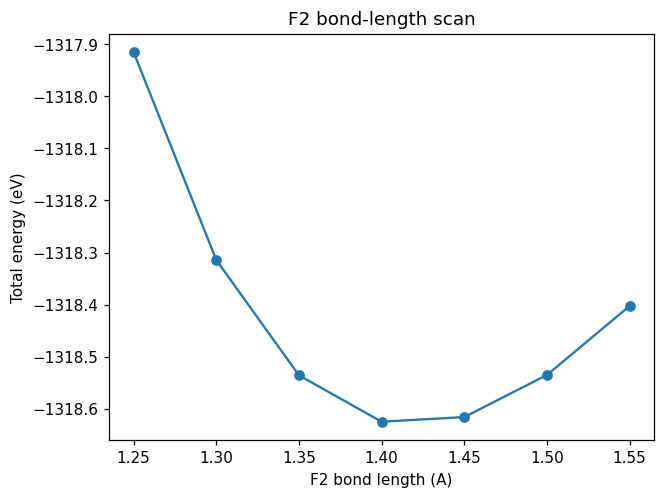

In [18]:
plt.plot(bond_lengths, energies, 'o-')
plt.xlabel('F2 bond length (A)')
plt.ylabel('Total energy (eV)')
plt.title('F2 bond-length scan')
plt.show()


In [19]:
# Fit a parabola near the minimum: E(d) ~ E0 + 0.5*k*(d-d0)^2
coeffs = np.polyfit(bond_lengths, energies, 2)   # [a, b, c] for a*d^2+b*d+c
a, b, c = coeffs
d0 = -b / (2 * a)          # vertex of the parabola = equilibrium bond length
k_eV_per_A2 = 2 * a        # curvature -> force constant
print(f'Equilibrium bond length: {d0:.3f} A  ')

# Convert the force constant to a vibrational wavenumber using the
# reduced mass of C-O and standard unit conversions.
import scipy.constants as sc
k_SI = k_eV_per_A2 * sc.e * 1e20               # eV/A^2 -> J/m^2
mu = (19 * 19) / (19 + 19) * sc.atomic_mass  # reduced mass, kg
omega = np.sqrt(k_SI / mu)                      # rad/s
wavenumber = omega / (2 * np.pi * sc.c) / 100    # -> cm^-1
print(f'Estimated vibrational wavenumber: {wavenumber:.0f} cm^-1  ')
print('bond strength k:',k_SI)

Equilibrium bond length: 1.434 A  
Estimated vibrational wavenumber: 1091 cm^-1  
bond strength k: 665.818832615907


Being the most electronegetive element, we would estiate it to have one of the highest bond strengt, but we can see that it's estimated bond strength (around 665) is much less than that of N2 (around 3300)

**NO — an odd-electron molecule (with 11 valence count). Run the same closed-shell-vs-spin-polarized comparison you did for O₂. What magnetization do you get, and how does NO's case differ from both CO (0 unpaired) and O₂ (2 unpaired)?**

In [21]:
pseudopotentials = {'N': pseudo_filename('N'),'O': pseudo_filename('O')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'smearing', 'degauss': 0.02},
    'electrons': {'conv_thr': 1.0e-8},
}


In [24]:
no = make_boxed_molecule(['N', 'O'], [[0, 0, 0], [0, 0, 1.15]])

# Run 1: no spin polarization allowed (forces a closed-shell solution)
input_data_nospin = dict(input_data)
input_data_nospin['system'] = dict(input_data['system'])
no.calc = Espresso(profile=profile, pseudopotentials= pseudopotentials,
                    input_data=input_data_nospin, kpts=(1, 1, 1))
e_nospin = no.get_potential_energy()
print(f'NO energy, spin-restricted:  {e_nospin:.4f} eV')

NO energy, spin-restricted:  -710.4302 eV


In [25]:
input_data_spin = dict(input_data)
input_data_spin['system'] = dict(input_data['system'])
input_data_spin['system']['nspin'] = 2
input_data_spin['system']['tot_magnetization'] = 1.0

no_spin = make_boxed_molecule(['N', 'O'], [[0, 0, 0], [0, 0, 1.15]])
no_spin.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=input_data_spin, kpts=(1, 1, 1))
e_spin = no_spin.get_potential_energy()


def read_total_magnetization(pwo_file='espresso.pwo'):
    with open(pwo_file) as f:
        lines = f.readlines()
    for line in reversed(lines):   # last occurrence = final converged value
        if 'total magnetization' in line:
            return float(line.split('=')[1].split('Bohr')[0].strip())
    raise RuntimeError(f"Couldn't find 'total magnetization' in {pwo_file}")

magmom = read_total_magnetization()

print(f'NO energy, spin-polarized:   {e_spin:.4f} eV')
print(f'Energy lowering from allowing spin: {e_nospin - e_spin:.4f} eV')
print(f'Converged total magnetization: {magmom:.2f} Bohr magnetons '
      f'(2.0 means 2 unpaired electrons)')

NO energy, spin-polarized:   -710.6599 eV
Energy lowering from allowing spin: 0.2297 eV
Converged total magnetization: 1.00 Bohr magnetons (2.0 means 2 unpaired electrons)


We can see that the spin polarized calculation wit 1 unpaired electron is more stable as it has lower energy.

Let us also do the spin polarized calculation for the other molecules in this assignment

**N2**

In [29]:
pseudopotentials = {'N': pseudo_filename('N')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'smearing', 'degauss': 0.02},
    'electrons': {'conv_thr': 1.0e-8},
}
no = make_boxed_molecule(['N', 'N'], [[0, 0, 0], [0, 0, 1.127]])

# Run 1: no spin polarization allowed (forces a closed-shell solution)
input_data_nospin = dict(input_data)
input_data_nospin['system'] = dict(input_data['system'])
no.calc = Espresso(profile=profile, pseudopotentials= pseudopotentials,
                    input_data=input_data_nospin, kpts=(1, 1, 1))
e_nospin = no.get_potential_energy()
print(f'energy, spin-restricted:  {e_nospin:.4f} eV')
input_data_spin = dict(input_data)
input_data_spin['system'] = dict(input_data['system'])
input_data_spin['system']['nspin'] = 2
input_data_spin['system']['tot_magnetization'] = 1.0

no_spin = make_boxed_molecule(['N', 'N'], [[0, 0, 0], [0, 0, 1.127]])
no_spin.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=input_data_spin, kpts=(1, 1, 1))
e_spin = no_spin.get_potential_energy()


def read_total_magnetization(pwo_file='espresso.pwo'):
    with open(pwo_file) as f:
        lines = f.readlines()
    for line in reversed(lines):   # last occurrence = final converged value
        if 'total magnetization' in line:
            return float(line.split('=')[1].split('Bohr')[0].strip())
    raise RuntimeError(f"Couldn't find 'total magnetization' in {pwo_file}")

magmom = read_total_magnetization()

print(f' energy, spin-polarized:   {e_spin:.4f} eV')
print(f'Energy lowering from allowing spin: {e_nospin - e_spin:.4f} eV')
print(f'Converged total magnetization: {magmom:.2f} Bohr magnetons '
      f'(2.0 means 2 unpaired electrons)')


energy, spin-restricted:  -548.0045 eV
 energy, spin-polarized:   -544.4336 eV
Energy lowering from allowing spin: -3.5709 eV
Converged total magnetization: 1.00 Bohr magnetons (2.0 means 2 unpaired electrons)


This shows that the paired electron state is more stable than having unpaied electrons in N2

**Cl2**

In [30]:
pseudopotentials = {'Cl': pseudo_filename('Cl')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'smearing', 'degauss': 0.02},
    'electrons': {'conv_thr': 1.0e-8},
}
no = make_boxed_molecule(['Cl', 'Cl'], [[0, 0, 0], [0, 0, 2.026]])

# Run 1: no spin polarization allowed (forces a closed-shell solution)
input_data_nospin = dict(input_data)
input_data_nospin['system'] = dict(input_data['system'])
no.calc = Espresso(profile=profile, pseudopotentials= pseudopotentials,
                    input_data=input_data_nospin, kpts=(1, 1, 1))
e_nospin = no.get_potential_energy()
print(f'energy, spin-restricted:  {e_nospin:.4f} eV')
input_data_spin = dict(input_data)
input_data_spin['system'] = dict(input_data['system'])
input_data_spin['system']['nspin'] = 2
input_data_spin['system']['tot_magnetization'] = 1.0

no_spin = make_boxed_molecule(['Cl', 'Cl'], [[0, 0, 0], [0, 0, 2.026]])
no_spin.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=input_data_spin, kpts=(1, 1, 1))
e_spin = no_spin.get_potential_energy()


def read_total_magnetization(pwo_file='espresso.pwo'):
    with open(pwo_file) as f:
        lines = f.readlines()
    for line in reversed(lines):   # last occurrence = final converged value
        if 'total magnetization' in line:
            return float(line.split('=')[1].split('Bohr')[0].strip())
    raise RuntimeError(f"Couldn't find 'total magnetization' in {pwo_file}")

magmom = read_total_magnetization()

print(f' energy, spin-polarized:   {e_spin:.4f} eV')
print(f'Energy lowering from allowing spin: {e_nospin - e_spin:.4f} eV')
print(f'Converged total magnetization: {magmom:.2f} Bohr magnetons '
      f'(2.0 means 2 unpaired electrons)')

energy, spin-restricted:  -905.7901 eV
 energy, spin-polarized:   -904.6592 eV
Energy lowering from allowing spin: -1.1309 eV
Converged total magnetization: 1.00 Bohr magnetons (2.0 means 2 unpaired electrons)


This once again shows that Cl2 is more stable in its paired state

**F2**

In [32]:
pseudopotentials = {'F': pseudo_filename('F')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'smearing', 'degauss': 0.02},
    'electrons': {'conv_thr': 1.0e-8},
}
no = make_boxed_molecule(['F', 'F'], [[0, 0, 0], [0, 0, 1.434]])

# Run 1: no spin polarization allowed (forces a closed-shell solution)
input_data_nospin = dict(input_data)
input_data_nospin['system'] = dict(input_data['system'])
no.calc = Espresso(profile=profile, pseudopotentials= pseudopotentials,
                    input_data=input_data_nospin, kpts=(1, 1, 1))
e_nospin = no.get_potential_energy()
print(f'energy, spin-restricted:  {e_nospin:.4f} eV')
input_data_spin = dict(input_data)
input_data_spin['system'] = dict(input_data['system'])
input_data_spin['system']['nspin'] = 2
input_data_spin['system']['tot_magnetization'] = 1.0

no_spin = make_boxed_molecule(['F', 'F'], [[0, 0, 0], [0, 0, 1.434]])
no_spin.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=input_data_spin, kpts=(1, 1, 1))
e_spin = no_spin.get_potential_energy()


def read_total_magnetization(pwo_file='espresso.pwo'):
    with open(pwo_file) as f:
        lines = f.readlines()
    for line in reversed(lines):   # last occurrence = final converged value
        if 'total magnetization' in line:
            return float(line.split('=')[1].split('Bohr')[0].strip())
    raise RuntimeError(f"Couldn't find 'total magnetization' in {pwo_file}")

magmom = read_total_magnetization()

print(f' energy, spin-polarized:   {e_spin:.4f} eV')
print(f'Energy lowering from allowing spin: {e_nospin - e_spin:.4f} eV')
print(f'Converged total magnetization: {magmom:.2f} Bohr magnetons '
      f'(2.0 means 2 unpaired electrons)')

energy, spin-restricted:  -1318.6276 eV
 energy, spin-polarized:   -1317.3537 eV
Energy lowering from allowing spin: -1.2739 eV
Converged total magnetization: 1.00 Bohr magnetons (2.0 means 2 unpaired electrons)


Again , this shows F2 is stable without unpaired electrons

# Discuss/Explain

**A 12 Å cubic box was used for both CO and O₂ without testing whether that's actually big enough. Propose a concrete experiment (using tools already in this notebook) that would tell you whether 12 Å is big enough, and explain what result would tell you it isn't.**

We could change box size through various values (say 8,9,10,11,12,13,..) and see the energy value obtained for each size. Once the energy value stops changing between a box size and the next (within some threshold , say 10^-9 ) we can say that we have good box size. If 12 is not big enough, there would be a significant change in energy between box size of 12 and box size of 13.

**The parabola that was fit to the CO bond-length scan is only a good approximation very close to the minimum. Looking at the E vs. bond-length plot, over roughly what range of bond lengths would you trust the parabolic fit, and where does it visibly start to break down? Why would a real (anharmonic) potential and a parabola necessarily disagree away from the minimum?**

Roughly looking, the parabola appears to be a good fit between 1.1 and 1.2 angstorms. After 1.25 on the right and 1.05 on the left, the fit visibly starts to break down. An anharmonic potential is by definition asymmetrical about its minima , this contradicts a parabola, which is symmetrical about its minima and hence a parabolic fit will necessarily disagree away from the minimum

**CO turned out to have zero net magnetization and O₂ has two unpaired electrons. Both are diatomic molecules with electrons filling the same general set of molecular orbitals. What's different about their electron counts or orbital energetics that explains why one pairs up completely and the other doesn't?**

The last two electrons of CO enter σ2p orbital and are hence paired. On the other hand, the last two electrons of O2 enter 𝜋*2p which has two orbitals 𝜋 *2px and 𝜋 *2py, which are degenerate. So one of the electrons go to 𝜋 *2px and the other goes to 𝜋 *2py, giving rise to two unpaired electrons.



